In [1]:
import pandas as pd
import rasterio
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

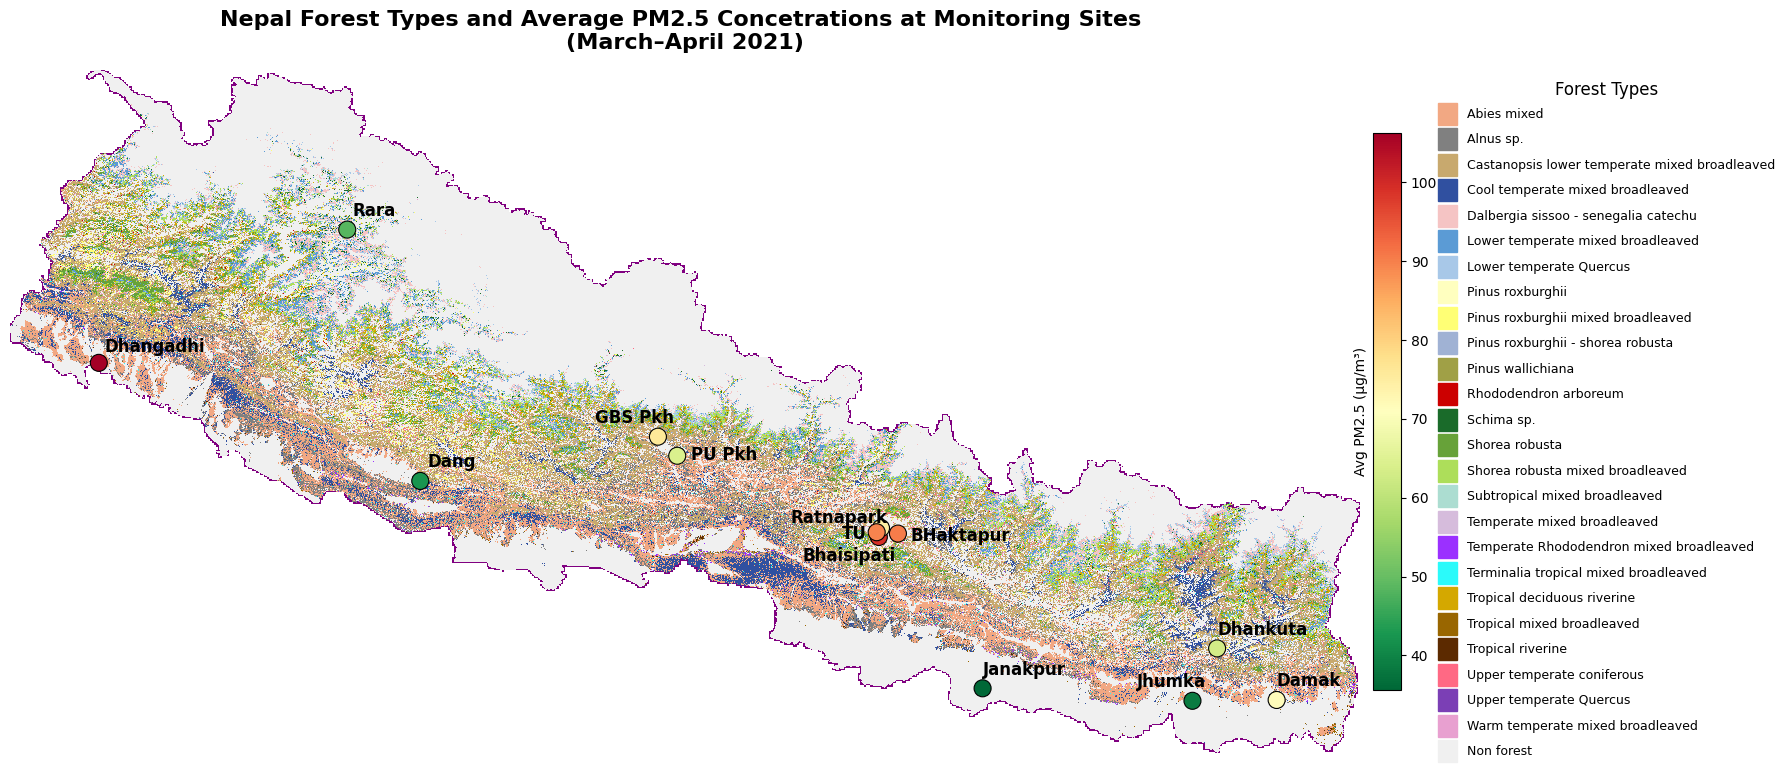

In [12]:
tifFile = "/Users/anehernandezarista/Holmes Summer 2026/Forest Types of Nepal/data/NepalForestType.tif"

forest_types = {
    1:  ("Abies mixed",                                   "#F2A883"),
    2:  ("Alnus sp.",                                     "#808080"),
    3:  ("Castanopsis lower temperate mixed broadleaved", "#C8A96E"),
    4:  ("Cool temperate mixed broadleaved",              "#3050A0"),
    5:  ("Dalbergia sissoo - senegalia catechu",          "#F5C4C4"),
    6:  ("Lower temperate mixed broadleaved",             "#5B9BD5"),
    7:  ("Lower temperate Quercus",                       "#A8C8E8"),
    8:  ("Pinus roxburghii",                              "#FFFFBF"),
    9:  ("Pinus roxburghii mixed broadleaved",            "#FFFF75"),
    10: ("Pinus roxburghii - shorea robusta",             "#A0B2D4"),
    11: ("Pinus wallichiana",                             "#A0A046"),
    12: ("Rhododendron arboreum",                         "#CC0000"),
    13: ("Schima sp.",                                    "#1A6B2A"),
    14: ("Shorea robusta",                                "#67A239"),
    15: ("Shorea robusta mixed broadleaved",              "#ADDE5A"),
    16: ("Subtropical mixed broadleaved",                 "#ACDDD1"),
    17: ("Temperate mixed broadleaved",                   "#D6BCDC"),
    18: ("Temperate Rhododendron mixed broadleaved",      "#9B30FF"),
    19: ("Terminalia tropical mixed broadleaved",         "#2BFAFA"),
    20: ("Tropical deciduous riverine",                   "#D4A800"),
    21: ("Tropical mixed broadleaved",                    "#996600"),
    22: ("Tropical riverine",                             "#5C2A00"),
    23: ("Upper temperate coniferous",                    "#FF6984"),
    24: ("Upper temperate Quercus",                       "#7B3FB5"),
    25: ("Warm temperate mixed broadleaved",              "#E8A0D0"),
    26: ("Non forest",                                    "#F0F0F0"),
}

# Read raster at 1/3 resolution for faster plotting
with rasterio.open(tifFile) as ds:
    data = ds.read(1, out_shape=(ds.height // 3, ds.width // 3),
                   resampling=Resampling.nearest).astype(float)
    extent = [ds.bounds.left, ds.bounds.right, ds.bounds.bottom, ds.bounds.top]

data[data == -128] = np.nan  # makes background transparent

# Build colormap
n = 27
colors = ["white"] * n
for val, (label, color) in forest_types.items():
    colors[val] = color

cmap = ListedColormap(colors)
cmap.set_bad(color="#800080")  # purple for area outside Nepal
bounds = np.arange(-0.5, n + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

# Station data
xl = pd.ExcelFile("DOE_Nepal_2021.xlsx")
records = []

for sheet in xl.sheet_names:
    df = pd.read_excel(xl, sheet_name=sheet)
    df.columns = ['date', 'pm25', 'pm10', 'tsp', 'lat', 'lon']
    df['date'] = pd.to_datetime(df['date'])
    mask = (df['date'].dt.month >= 3) & (df['date'].dt.month <= 4)
    sub = df[mask]
    records.append({
        'station': sheet,
        'lat': df['lat'].dropna().iloc[0],
        'lon': df['lon'].dropna().iloc[0],
        'avg_pm25': sub['pm25'].mean()
    })

df_stations = pd.DataFrame(records)
df_stations = df_stations[~df_stations['station'].isin(['Biratnagar', 'SImara', 'Nepalgunj', 'Bhimdatta'])]

# Label offsets for station names
offsets = {
    'Ratnapark':  (-65, 4), 'TU': (-25, -5), 'BHaktapur': (9, -5),
    'Bhaisipati': (-55, -17), 'GBS Pkh': (-45, 10), 'PU Pkh': (10, -3),
    'Jhumka': (-40, 10), 'Damak': (0, 10), 'Dhankuta': (0, 10),
    'Janakpur': (0, 10), 'Dang': (5, 10), 'Dhangadhi': (4, 8), 'Rara': (4, 10),
}

#Plotting
fig, ax = plt.subplots(figsize=(18, 9), facecolor="white")
ax.set_facecolor("white")

# forest type raster
ax.imshow(data, cmap=cmap, norm=norm, extent=extent, interpolation='nearest', zorder=1)

# PM2.5 station dots
sc = ax.scatter(
    df_stations['lon'],
    df_stations['lat'],
    c=df_stations['avg_pm25'],
    cmap='RdYlGn_r',
    s=150,
    zorder=5,
    edgecolors='black',
    linewidths=0.8
)

# station labels
for idx, row in df_stations.iterrows():
    ax.annotate(
        row['station'],
        xy=(row['lon'], row['lat']),
        xytext=offsets.get(row['station'], (5, 5)),
        textcoords='offset points',
        fontsize=12,
        fontweight='bold',
        color='black',
        zorder=6
    )

# Colorbar for PM2.5
cbar = plt.colorbar(sc, ax=ax, fraction=0.020, pad=0.01)
cbar.set_label('Avg PM2.5 (µg/m³)', fontsize=10)
cbar.ax.yaxis.set_label_position('left')

patches = [mpatches.Patch(color=color, label=label) for _, (label, color) in forest_types.items()]
ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left',
          fontsize=9, frameon=False, title="Forest Types", title_fontsize=12,
          handlelength=1.5, handleheight=2.3, labelspacing=0.3)

ax.set_title("Nepal Forest Types and Average PM2.5 Concetrations at Monitoring Sites \n(March–April 2021)",
              fontsize=16, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()